In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

# corpus
corpus = "I like natural language processing and machine learning".lower().split()

# vocabulary
vocab = list(set(corpus))
word_to_idx = {w:i for i,w in enumerate(vocab)}
idx_to_word = {i:w for w,i in word_to_idx.items()}
vocab_size = len(vocab)

# parameters
window_size = 2
embedding_dim = 20
negative_samples = 5

# training pairs
pairs = []
for i,word in enumerate(corpus):
    target = word_to_idx[word]
    for j in range(-window_size,window_size+1):
        if j==0: continue
        if 0 <= i+j < len(corpus):
            context = word_to_idx[corpus[i+j]]
            pairs.append((target,context))

# model
class SGNS(nn.Module):
    def __init__(self,vocab_size,embed_dim):
        super().__init__()
        self.input_embed = nn.Embedding(vocab_size,embed_dim)
        self.output_embed = nn.Embedding(vocab_size,embed_dim)

    def forward(self,target,context,negatives):
        v = self.input_embed(target)
        u = self.output_embed(context)
        score = torch.sum(v*u,dim=1)
        pos_loss = torch.log(torch.sigmoid(score))

        neg_u = self.output_embed(negatives)
        neg_score = torch.bmm(neg_u, v.unsqueeze(2)).squeeze(-1) # Changed .squeeze() to .squeeze(-1)
        neg_loss = torch.sum(torch.log(torch.sigmoid(-neg_score)),dim=1)

        return -(pos_loss + neg_loss).mean()

model = SGNS(vocab_size,embedding_dim)
optimizer = optim.Adam(model.parameters(),lr=0.01)

# training
for epoch in range(200):

    total_loss = 0

    for target,context in pairs:

        negatives = torch.tensor(
            random.sample(range(vocab_size),negative_samples)
        )

        target = torch.tensor([target])
        context = torch.tensor([context])
        negatives = negatives.unsqueeze(0)

        optimizer.zero_grad()

        loss = model(target,context,negatives)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if epoch % 50 == 0:
        print(epoch,total_loss)

0 305.50375628471375
50 53.501010060310364
100 55.44126558303833
150 53.46009051799774


In [8]:
import torch.nn.functional as F

def get_similarity(word1, word2):
    if word1 not in word_to_idx or word2 not in word_to_idx:
        return "Word not in vocab"

    # 入力側の埋め込みベクトルを取得
    v1 = model.input_embed(torch.tensor([word_to_idx[word1]]))
    v2 = model.input_embed(torch.tensor([word_to_idx[word2]]))

    # コサイン類似度を計算 (1に近いほど似ている)
    sim = F.cosine_similarity(v1, v2)
    return sim.item()

# 例: 'learning' と他の単語の類似度を比較
test_word = 'learning'
print(f"--- Similarity with '{test_word}' ---")
for w in vocab:
    if w != test_word:
        print(f"{w}: {get_similarity(test_word, w):.4f}")

--- Similarity with 'learning' ---
natural: -0.2638
like: 0.0754
and: -0.0474
language: 0.5907
i: 0.0675
machine: 0.3924
processing: 0.1463


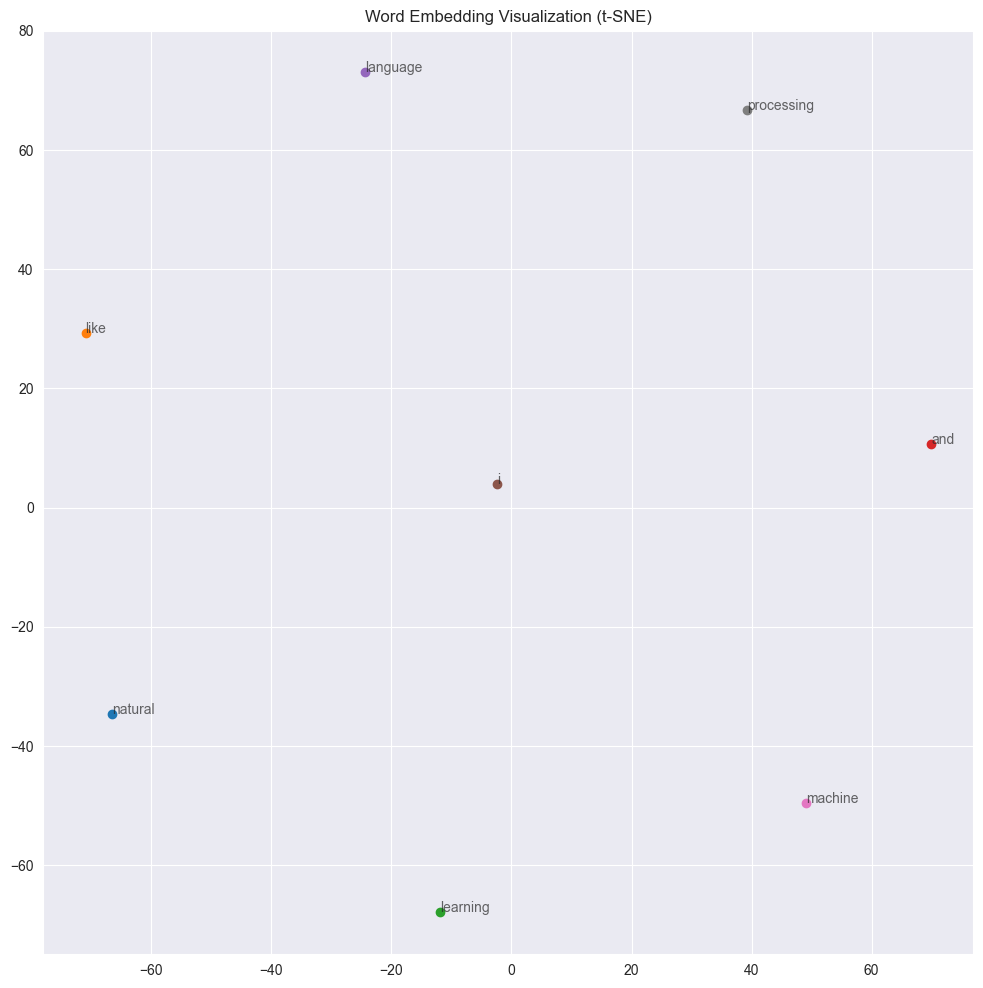

In [9]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def visualize_embeddings(model, vocab, n_words=100):
    # 最初のn個の単語のベクトルを取り出す
    embeddings = model.input_embed.weight.detach().cpu().numpy()[:n_words]
    words = vocab[:n_words]

    # t-SNEで2次元に圧縮
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(words)-1))
    vectors_2d = tsne.fit_transform(embeddings)

    # 描画
    plt.figure(figsize=(12, 12))
    for i, word in enumerate(words):
        plt.scatter(vectors_2d[i, 0], vectors_2d[i, 1])
        plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), alpha=0.7)
    plt.title("Word Embedding Visualization (t-SNE)")
    plt.grid(True)
    plt.show()

visualize_embeddings(model, vocab)

In [14]:
def visualize_embeddings(model, vocab, n_words=100):
    # 1. Get embeddings
    embeddings = model.input_embed.weight.detach().cpu().numpy()[:n_words]
    labels = vocab[:n_words]
    n_samples = embeddings.shape[0]

    # 2. Guard: Check if we have enough data
    if n_samples < 2:
        print(f"Not enough samples for t-SNE (n_samples={n_samples}).")
        return

    # 3. Dynamic Perplexity Adjustment
    # Perplexity should generally be less than the number of samples.
    # A common rule of thumb is min(30, n_samples - 1).
    current_perplexity = min(30, n_samples - 1)

    # 4. Run t-SNE
    tsne = TSNE(
        n_components=2, 
        random_state=42, 
        perplexity=current_perplexity,
        init='pca', 
        learning_rate='auto'
    )
    vectors_2d = tsne.fit_transform(embeddings)

    # 5. Plotting
    plt.figure(figsize=(12, 10))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.5, c='blue')

    for i, label in enumerate(labels):
        plt.annotate(label, (vectors_2d[i, 0], vectors_2d[i, 1]), 
                     xytext=(5, 2), textcoords='offset points', 
                     ha='right', va='bottom', fontsize=9)

    plt.title(f"t-SNE Visualization (n_words={n_samples}, perplexity={current_perplexity})")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [15]:
# 'he' という単語に割り当てられている 50 次元のベクトルの「生データ」を見てみます
if 'he' in word_to_idx:
    he_idx = torch.tensor([word_to_idx['he']])
    # grad_fn が付いているのは、これが「学習によって更新される値」であることを示しています
    he_vector = model.input_embed(he_idx)

    print(f"単語 'he' のベクトル形式 (最初の10次元のみ):")
    print(he_vector.detach().numpy()[0][:10])

    print(f"\nベクトルの形状: {he_vector.shape} (embedding_dim が 50 なので 50 個の数値があります)")

In [16]:
!pip install datasets

  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 16.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 20.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 46.7 MB/s  0:00:00
Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl (15 kB)
Using cached aiosignal-1.4.0-py3-none-any.whl (7.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.2/34.2 MB 36.9 MB/s  0:00:00 eta 0:00:01
Using cached typer-0.24.1-py3-none-any.whl (56 kB)
Using cached annotated_doc-0.0.4-py3-no

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from datasets import load_dataset
import re

# 1. 大規模データのロード (WikiText-2のサブセットを使用)
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
# 最初の1000行程度に制限して学習時間を調整
raw_text = " ".join(dataset['text'][:1000]).lower()
words = re.findall(r'\w+', raw_text)

# 2. 語彙の構築 (頻度の低い単語を除外)
word_counts = Counter(words)
vocab = [w for w, c in word_counts.items() if c > 5]
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for w, i in word_to_idx.items()}
vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")

# 3. データセットクラスの定義
class SkipGramDataset(Dataset):
    def __init__(self, words, word_to_idx, window_size=2):
        self.data = []
        indices = [word_to_idx[w] for w in words if w in word_to_idx]
        for i, target in enumerate(indices):
            for j in range(max(0, i - window_size), min(len(indices), i + window_size + 1)):
                if i != j:
                    self.data.append((target, indices[j]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# 4. モデルの再定義 (バッチ処理対応)
class SGNS_Large(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.input_embed = nn.Embedding(vocab_size, embed_dim)
        self.output_embed = nn.Embedding(vocab_size, embed_dim)

    def forward(self, target, context, negatives):
        # target: [batch_size], context: [batch_size], negatives: [batch_size, neg_samples]
        v = self.input_embed(target) # [batch_size, embed_dim]
        u = self.output_embed(context) # [batch_size, embed_dim]

        pos_score = torch.sum(v * u, dim=1) # [batch_size]
        pos_loss = torch.log(torch.sigmoid(pos_score))

        neg_u = self.output_embed(negatives) # [batch_size, neg_samples, embed_dim]
        neg_score = torch.bmm(neg_u, v.unsqueeze(2)).squeeze(-1) # [batch_size, neg_samples]
        neg_loss = torch.sum(torch.log(torch.sigmoid(-neg_score)), dim=1)

        return -(pos_loss + neg_loss).mean()

# 5. 訓練の実行
window_size = 2
embedding_dim = 50
negative_samples = 5
batch_size = 512

ds = SkipGramDataset(words, word_to_idx, window_size)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

model = SGNS_Large(vocab_size, embedding_dim)
optimizer = optim.Adam(model.parameters(), lr=0.005)

print("Training...")
for epoch in range(10):
    total_loss = 0
    for target, context in dl:
        negatives = torch.randint(0, vocab_size, (target.size(0), negative_samples))

        optimizer.zero_grad()
        loss = model(target, context, negatives)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dl):.4f}")

/Users/atsushihatakeyama/code/NLP-playbook/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating validation split: 100%|██████████| 3760/3760 [00:00<00:00, 538134.96 examples/s]


Vocab size: 1233
Training...
Epoch 1, Loss: 12.2458
Epoch 2, Loss: 6.2398
Epoch 3, Loss: 3.6036
Epoch 4, Loss: 2.6299
Epoch 5, Loss: 2.2751
Epoch 6, Loss: 2.0780
Epoch 7, Loss: 1.9414
Epoch 8, Loss: 1.8509
Epoch 9, Loss: 1.7713
Epoch 10, Loss: 1.7167


In [18]:
def get_similarity_updated(word1, word2):
    if word1 not in word_to_idx or word2 not in word_to_idx:
        return "Word not in vocab"
    v1 = model.input_embed(torch.tensor([word_to_idx[word1]]))
    v2 = model.input_embed(torch.tensor([word_to_idx[word2]]))
    return torch.nn.functional.cosine_similarity(v1, v2).item()

test_word = 'he'
if test_word in word_to_idx:
    print(f"--- Similarity with '{test_word}' ---")
    results = []
    for w in vocab[:100]: # 最初の100語から比較
        if w != test_word:
            results.append((w, get_similarity_updated(test_word, w)))
    for w, s in sorted(results, key=lambda x: x[1], reverse=True)[:10]:
        print(f"{w}: {s:.4f}")
else:
    print(f"'{test_word}' is not in vocab.")

--- Similarity with 'he' ---
the: 0.6347
team: 0.5832
a: 0.5828
for: 0.5717
in: 0.5706
from: 0.5499
by: 0.5490
game: 0.5480
was: 0.5463
that: 0.5365
